In [ ]:
# ============================================================
# Cell 1 — Setup & konfigurasi + data fundamental
# Import, konstanta, download USDIDR + DXY/VIX/Brent/IHSG/FRED
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from datetime import datetime, timedelta

from sklearn.preprocessing import MaxAbsScaler

import tensorflow as tf  # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout  # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # type: ignore
from tensorflow.keras.regularizers import l2  # type: ignore

# === Konstanta global ===
START         = '2001-06-28'
END           = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')
WINDOW        = 30
HORIZON       = 7
SKIP          = 30
FORECAST_DAYS = HORIZON
MC_SAMPLES    = 500

# === Path output ===
RUN_TS       = datetime.now().strftime('%Y%m%d_%H%M%S')
NOTEBOOK_DIR = os.getcwd()
RESULT_DIR   = os.path.join(NOTEBOOK_DIR, 'Result', RUN_TS)
os.makedirs(RESULT_DIR, exist_ok=True)
print(f"Output folder: {RESULT_DIR}")

# === Download data utama USDIDR=X ===
df = yf.download('USDIDR=X', start=START, end=END, progress=False)
df.columns  = df.columns.droplevel(1)
df['Close'] = df['Close'].ffill()
print(f"Rentang       : {df.index[0].date()} s.d. {df.index[-1].date()}")
print(f"Total rows    : {len(df)}")
print(f"Close terakhir: {df['Close'].iloc[-1]:,.2f} IDR  ({df.index[-1].date()})")

# === Helper: download return harian dari yfinance ===
def _yf_return(ticker, name, start, end, add_lag=False):
    """Download close, hitung pct_change return harian; opsional tambah lag_1."""
    try:
        raw = yf.download(ticker, start=start, end=end, progress=False)
        if raw.empty:
            raise ValueError("data kosong")
        raw.columns = raw.columns.droplevel(1)
        ret = raw['Close'].pct_change().rename(f'{name}_return')
        out = pd.DataFrame(ret)
        if add_lag:
            out[f'{name}_lag1'] = ret.shift(1)
        return out
    except Exception as e:
        print(f"WARNING: Gagal download {ticker} ({name}): {e}")
        return None

dxy_df   = _yf_return('DX-Y.NYB', 'dxy',   START, END, add_lag=True)
vix_df   = _yf_return('^VIX',     'vix',   START, END, add_lag=True)
brent_df = _yf_return('BZ=F',     'brent', START, END, add_lag=False)
ihsg_df  = _yf_return('^JKSE',    'ihsg',  START, END, add_lag=False)

# === Helper: download series FRED via direct URL (tanpa pandas_datareader) ===
# Menggunakan requests langsung ke FRED public CSV endpoint — tidak butuh API key.

def _fred_daily(series_id, col_name, start, end, mom_pct=False):
    """Download FRED bulanan via URL, resample ke harian dengan ffill.
    mom_pct=True: hitung MoM pct_change SEBELUM resample.
    Fallback: isi nol jika gagal download.
    """
    try:
        import requests, io
        url  = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        raw  = pd.read_csv(io.StringIO(resp.text), index_col=0, parse_dates=True)
        raw.columns = [col_name]
        # FRED pakai '.' untuk nilai kosong
        raw  = raw[raw[col_name] != '.'].copy()
        raw[col_name] = raw[col_name].astype(float)
        raw  = raw[raw.index >= pd.Timestamp(start)]
        if mom_pct:
            raw = raw.pct_change().fillna(0)
        daily_idx = pd.date_range(start=raw.index.min(),
                                  end=pd.Timestamp(end), freq='D')
        return raw.reindex(daily_idx).ffill().bfill()
    except Exception as e:
        print(f'WARNING: Gagal download FRED {series_id}: {e}. Diisi nol.')
        idx = pd.date_range(start=start, end=end, freq='D')
        return pd.DataFrame({col_name: 0.0}, index=idx)

bi_rate_df  = _fred_daily('IR3TIB01IDM156N', 'bi_rate',  START, END)
fed_rate_df = _fred_daily('FEDFUNDS',         'fed_rate', START, END)
us_cpi_df   = _fred_daily('CPIAUCSL',          'us_cpi',  START, END, mom_pct=True)
id_cpi_df   = _fred_daily('IDNCPIALLMINMEI',   'id_cpi',  START, END, mom_pct=True)

# === Rate spread = BI Rate - Fed Rate ===
_bi  = bi_rate_df['bi_rate'].reindex(df.index).ffill().bfill()
_fed = fed_rate_df['fed_rate'].reindex(df.index).ffill().bfill()
df['rate_spread'] = (_bi - _fed).values

# === Merge semua ke df ===
for _fdf in [dxy_df, vix_df, brent_df, ihsg_df,
             bi_rate_df, fed_rate_df, us_cpi_df, id_cpi_df]:
    if _fdf is not None:
        for _col in _fdf.columns:
            df[_col] = _fdf[_col].reindex(df.index).ffill().bfill()

# Pastikan semua kolom fundamental ada; isi 0 jika download gagal
_FUND_COLS = [
    'dxy_return', 'dxy_lag1',
    'vix_return', 'vix_lag1',
    'brent_return', 'ihsg_return',
    'bi_rate', 'fed_rate', 'us_cpi', 'id_cpi', 'rate_spread',
]
for _c in _FUND_COLS:
    if _c not in df.columns:
        print(f"WARNING: {_c} tidak tersedia, diisi 0.")
        df[_c] = 0.0
    df[_c] = df[_c].fillna(0.0)

print(f"\nFitur fundamental tersedia : {_FUND_COLS}")
print(f"Shape df setelah merge     : {df.shape}")

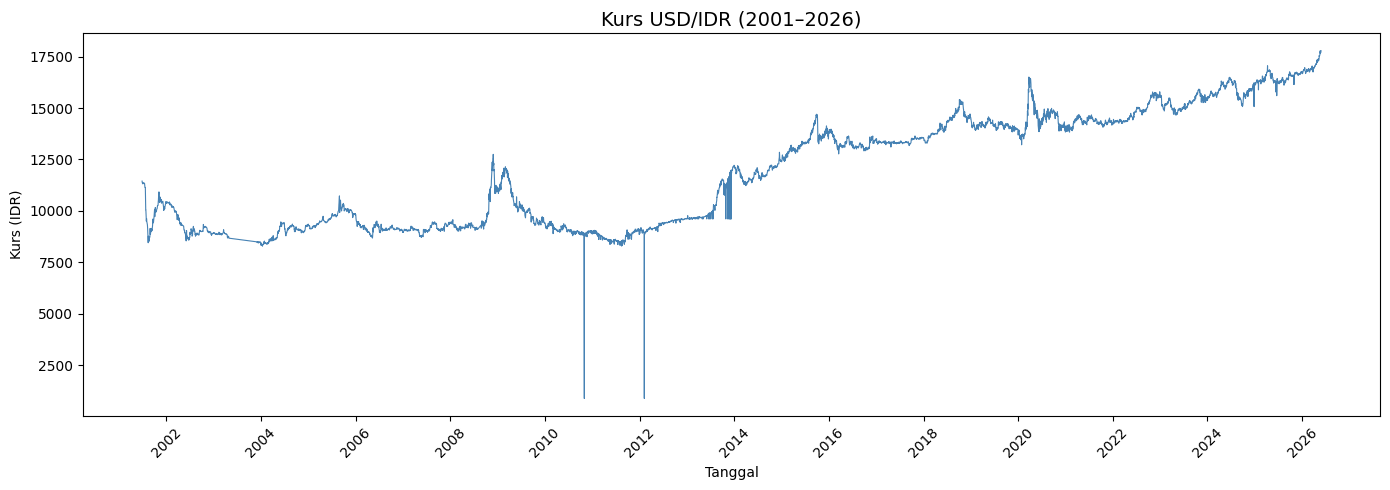

In [2]:
# ============================================================
# Cell 2 — Visualisasi historis kurs USD/IDR
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], linewidth=0.8, color='steelblue')
ax.set_title(f'Kurs USD/IDR ({df.index[0].year}–{df.index[-1].year})', fontsize=14)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Kurs (IDR)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_historis_kurs_usdidr.png'), dpi=150)
plt.show()

In [ ]:
# ============================================================
# Cell 3 — Feature engineering
# 9 fitur teknikal (tidak berubah) + 11 fitur fundamental
# Total: 20 fitur. Semua fundamental di-shift(1) hindari lookahead.
# Scaler: MaxAbsScaler, fit HANYA pada baris training (no leakage).
# ============================================================

# === Array harga raw ===
data_raw = df['Close'].values.astype(float)
close    = data_raw
high     = df['High'].values.astype(float)
low      = df['Low'].values.astype(float)
N        = len(close)

# === Fitur teknikal (9) ===
close_diff     = np.zeros_like(close)
close_diff[1:] = close[1:] - close[:-1]

returns        = np.zeros_like(close)
returns[1:]    = (close[1:] - close[:-1]) / close[:-1]

hl_range       = (high - low) / close

def compute_rsi(prices, period=14):
    """RSI dengan Wilder's smoothing (alpha = 1/period)."""
    delta    = np.diff(prices, prepend=prices[0])
    gain     = np.where(delta > 0,  delta, 0.0)
    loss     = np.where(delta < 0, -delta, 0.0)
    avg_gain = pd.Series(gain).ewm(alpha=1/period, adjust=False).mean().values
    avg_loss = pd.Series(loss).ewm(alpha=1/period, adjust=False).mean().values
    rs       = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

rsi_14 = compute_rsi(close, period=14)

ema_7         = pd.Series(close).ewm(span=7,  adjust=False).mean().values
ema_21        = pd.Series(close).ewm(span=21, adjust=False).mean().values
ema_7_dev     = (close - ema_7)  / close
ema_21_dev    = (close - ema_21) / close
rolling_std_7 = pd.Series(close).rolling(7).std().fillna(0).values / close

dow   = df.index.dayofweek.values.astype(float)
month = df.index.month.values.astype(float)

# === Helper: ekstrak fitur fundamental dari df, shift(1), slice SKIP: ===
def _fund(col):
    """Shift 1 hari (hindari lookahead), fillna(0), slice SKIP: sebagai numpy array."""
    return df[col].shift(1).fillna(0).values.astype(float)[SKIP:]

# === Susun features_list: 9 teknikal + 11 fundamental ===
features_list = [
    # --- Teknikal (9) ---
    close_diff[SKIP:],
    returns[SKIP:],
    hl_range[SKIP:],
    rsi_14[SKIP:],
    ema_7_dev[SKIP:],
    ema_21_dev[SKIP:],
    rolling_std_7[SKIP:],
    dow[SKIP:]         / 4.0,
    (month[SKIP:] - 1) / 10.0,
    # --- Fundamental (11) ---
    _fund('dxy_return'),    # DXY return t-1
    _fund('dxy_lag1'),      # DXY return t-2
    _fund('vix_return'),    # VIX return t-1
    _fund('vix_lag1'),      # VIX return t-2
    _fund('brent_return'),  # Brent crude return t-1
    _fund('ihsg_return'),   # IHSG return t-1
    _fund('bi_rate'),       # BI Rate (bulanan, ffill) t-1
    _fund('fed_rate'),      # Fed Funds Rate t-1
    _fund('us_cpi'),        # US CPI MoM% t-1
    _fund('id_cpi'),        # ID CPI MoM% t-1
    _fund('rate_spread'),   # Spread BI-Fed t-1
]

feat_names = [
    'close_diff', 'return', 'hl_range', 'rsi_14',
    'ema_7_dev', 'ema_21_dev', 'rolling_std_7', 'dow', 'month',
    'dxy_ret_t1', 'dxy_ret_t2',
    'vix_ret_t1', 'vix_ret_t2',
    'brent_ret_t1', 'ihsg_ret_t1',
    'bi_rate', 'fed_rate', 'us_cpi', 'id_cpi', 'rate_spread',
]

feat       = np.column_stack(features_list)
N_FEATURES = feat.shape[1]

# === Split statis (level sequence), dihitung tanpa membuat sequence dulu ===
# len(X) == n_seq; nilainya sama dengan int(len(X)*0.8) di Cell 4.
n_seq = len(feat) - WINDOW - HORIZON + 1
split = int(n_seq * 0.8)

# === Scaler: MaxAbsScaler (nol & tanda terjaga → directional penalty sah) ===
# fit HANYA pada baris training (hindari data leakage test set).
# Wilayah training = semua baris yang dipakai input window seq training.
fit_rows        = split + WINDOW
feat_scaler     = MaxAbsScaler()
feat_scaler.fit(feat[:fit_rows])
features_scaled = feat_scaler.transform(feat)
target_scaled   = features_scaled[:, 0]

def inverse_close_diff(scaled_arr):
    """Inverse MaxAbsScaler kolom 0: X = X_scaled * scale_[0] (tanpa offset)."""
    arr = np.asarray(scaled_arr).reshape(-1)
    return arr * feat_scaler.scale_[0]

print(f"Fitur input ({N_FEATURES}): {feat_names}")
print(f"Shape features: {features_scaled.shape}  (skip {SKIP} baris warmup)")
print(f"Scaler        : MaxAbsScaler — fit pada {fit_rows} baris training (no leakage)")
print(f"Range close_diff: {close_diff[SKIP:].min():+.1f} s.d. {close_diff[SKIP:].max():+.1f} IDR")

In [ ]:
# ============================================================
# Cell 4 — Sequences + Walk-Forward Validation
# Walk-forward = evaluasi robust lintas waktu.
# RIGOR: scaler (MaxAbs) di-REFIT per fold pada baris training fold itu saja
#        → tidak ada leakage dari data masa depan ke scaler.
# Training final model tetap di Cell 5 (pakai global features_scaled).
# ============================================================

# ── Sliding window sequences ──────────────────────────────────────────────────
def create_sequences(features, target, window, horizon):
    """Sliding window: setiap sample = window hari fitur + horizon hari target."""
    X, y = [], []
    for i in range(window, len(features) - horizon + 1):
        X.append(features[i - window:i])
        y.append(target[i:i + horizon])
    return np.array(X), np.array(y)

# Versi ter-scaling global (untuk model final Cell 5/6/7)
X, y = create_sequences(features_scaled, target_scaled, WINDOW, HORIZON)
# Versi MENTAH (untuk WF: di-scaling ulang per fold dengan scale_ fold)
X_raw, y_raw = create_sequences(feat, feat[:, 0], WINDOW, HORIZON)

# ── Loss function (duplikat dari Cell 5 — dibutuhkan model WF) ───────────────
# Penalti arah valid karena MaxAbsScaler menjaga tanda & titik nol.
def directional_mse_loss(y_true, y_pred, alpha=0.3):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    dir_penalty = tf.reduce_mean(tf.nn.relu(-y_true * y_pred))
    return mse + alpha * dir_penalty

# ── Walk-Forward config ───────────────────────────────────────────────────────
# WF_FAST=True  → step=90, epochs=10  (~20 fold, ~10-20 mnt CPU)
# WF_FAST=False → step=30, epochs=20  (~62 fold, bisa >1 jam CPU)
WF_FAST       = True
WF_INIT_RATIO = 0.70
WF_STEP       = 90 if WF_FAST else 30
WF_EPOCHS     = 10 if WF_FAST else 20

init_train  = int(len(X) * WF_INIT_RATIO)
n_est_fold  = max(1, (len(X) - init_train) // WF_STEP)
print(f"Walk-Forward Validation{'  [FAST MODE]' if WF_FAST else ''}  (scaler refit per fold)")
print(f"  sequences  : {len(X)}  |  init_train : {init_train}")
print(f"  step       : {WF_STEP}  |  est. folds : {n_est_fold}")
print(f"  epochs/fold: {WF_EPOCHS}  (set WF_FAST=False untuk akurasi lebih tinggi)")

def _build_wf_model():
    from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add
    inp  = tf.keras.Input(shape=(WINDOW, N_FEATURES))
    x    = LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.3,
                kernel_regularizer=l2(1e-4))(inp)
    x    = Dropout(0.3)(x)
    attn = MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.1)(x, x)
    x    = LayerNormalization()(Add()([x, attn]))
    x    = LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.3,
                kernel_regularizer=l2(1e-4))(x)
    x    = Dropout(0.3)(x)
    out  = Dense(HORIZON)(x)
    m    = tf.keras.Model(inp, out)
    m.compile(optimizer='adam', loss=directional_mse_loss)
    return m

fold_records = []
train_end    = init_train

while train_end < len(X):
    test_end = min(train_end + WF_STEP, len(X))
    if test_end - train_end == 0:
        break

    # --- RIGOR: refit MaxAbsScaler hanya pada baris training fold ini ---
    # Baris training fold = semua baris yang dipakai input window seq training.
    scaler_fold = MaxAbsScaler().fit(feat[:train_end + WINDOW])
    s_fold      = scaler_fold.scale_                       # (N_FEATURES,), tanpa offset

    X_wf_tr = X_raw[:train_end]          / s_fold          # broadcast per-fitur
    y_wf_tr = y_raw[:train_end]          / s_fold[0]
    X_wf_te = X_raw[train_end:test_end]  / s_fold

    m_wf = _build_wf_model()
    m_wf.fit(
        X_wf_tr, y_wf_tr,
        epochs=WF_EPOCHS, batch_size=64, validation_split=0.1,
        callbacks=[EarlyStopping(patience=4, restore_best_weights=True, verbose=0)],
        verbose=0,
    )

    pred_sc = m_wf.predict(X_wf_te, verbose=0)
    sp      = data_raw[SKIP + WINDOW - 1 + train_end :
                       SKIP + WINDOW - 1 + train_end + len(X_wf_te)]
    p_diff  = pred_sc * s_fold[0]                          # inverse → IDR
    t_diff  = y_raw[train_end:test_end]                    # truth sudah IDR mentah
    p_price = sp[:, None] + np.cumsum(p_diff, axis=1)
    t_price = sp[:, None] + np.cumsum(t_diff, axis=1)

    fold_mae = float(np.mean(np.abs(p_price - t_price)))
    fold_dir = float(np.mean(np.sign(p_diff) == np.sign(t_diff))) * 100
    fold_id  = len(fold_records)

    fold_records.append({'fold': fold_id, 'mae': fold_mae, 'dir_acc': fold_dir,
                         'n_train': train_end, 'n_test': len(X_wf_te)})
    print(f"  Fold {fold_id:2d} | train={train_end:5d} | test={len(X_wf_te):3d} "
          f"| MAE={fold_mae:7.2f} IDR | DirAcc={fold_dir:.1f}%")

    train_end += WF_STEP
    del m_wf
    tf.keras.backend.clear_session()

# ── Hasil agregat ─────────────────────────────────────────────────────────────
wf_df       = pd.DataFrame(fold_records)
mean_mae_wf = wf_df['mae'].mean()
std_mae_wf  = wf_df['mae'].std()
mean_dir_wf = wf_df['dir_acc'].mean()
stable_wf   = bool(std_mae_wf < 0.20 * mean_mae_wf)

print(f"\n{'='*55}")
print(f"  Mean MAE   : {mean_mae_wf:,.2f} IDR")
print(f"  Std MAE    : {std_mae_wf:,.2f} IDR  "
      f"({std_mae_wf / mean_mae_wf * 100:.1f}% dari mean)")
print(f"  Mean Dir   : {mean_dir_wf:.1f}%")
print(f"  Stabilitas : {'STABIL ✓' if stable_wf else 'TIDAK STABIL ✗'}"
      f"  (rule: std < 20% mean)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(wf_df['fold'], wf_df['mae'], 'o-', color='steelblue', linewidth=1.5)
axes[0].axhline(mean_mae_wf, color='tomato', linestyle='--',
                label=f'Mean = {mean_mae_wf:.0f} IDR')
axes[0].fill_between(wf_df['fold'],
                     mean_mae_wf - std_mae_wf, mean_mae_wf + std_mae_wf,
                     alpha=0.2, color='tomato', label='±1 Std')
axes[0].set_title('MAE per Fold — Walk-Forward')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('MAE (IDR)')
axes[0].legend()

axes[1].plot(wf_df['fold'], wf_df['dir_acc'], 's-', color='seagreen', linewidth=1.5)
axes[1].axhline(mean_dir_wf, color='tomato', linestyle='--',
                label=f'Mean = {mean_dir_wf:.1f}%')
axes[1].axhline(50, color='gray', linestyle=':', label='Random 50%')
axes[1].set_title('Directional Accuracy per Fold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100); axes[1].legend()

plt.suptitle(f'Walk-Forward Validation  {"[FAST]" if WF_FAST else ""}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_walkforward.png'), dpi=150)
plt.show()

print(pd.DataFrame({
    'Metrik'      : ['Mean MAE', 'Std MAE', 'Mean Dir Acc'],
    'Nilai'       : [f"{mean_mae_wf:,.2f} IDR",
                     f"{std_mae_wf:,.2f} IDR  ({std_mae_wf/mean_mae_wf*100:.1f}%)",
                     f"{mean_dir_wf:.1f}%"],
    'Interpretasi': ['Rata-rata error absolut',
                     f"{'STABIL ✓' if stable_wf else 'TIDAK STABIL ✗'}  (target: std < 20% mean)",
                     'Target >60% untuk lebih baik dari random'],
}).to_string(index=False))

# ── Split statis untuk Cell 5 (pakai global features_scaled, no leakage) ───────
# split sudah dihitung di Cell 3; len(X)*0.8 menghasilkan nilai yang sama.
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"\nSplit 80/20 untuk Cell 5: X_train={X_train.shape}  X_test={X_test.shape}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 64)    │     21,760 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 7)         │        231 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,175 (199.90 KB)

 Trainable params: 51,175 (199.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0289 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0119 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0102 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0087 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0075 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0064 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0055 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 8/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0048 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 9/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0042 - val_loss: 0.0030 - learning_rate:

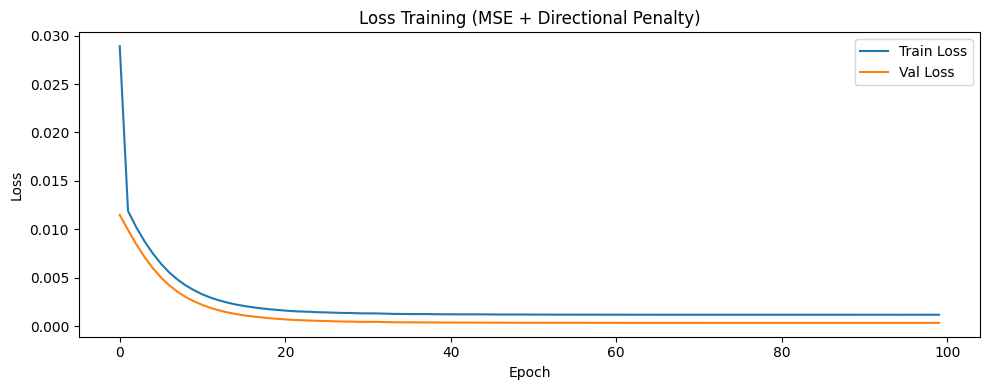

In [5]:
# ============================================================
# Cell 5 — Bangun & latih model
# Arsitektur: LSTM(64) → Dropout → MultiHeadAttention+LN → LSTM(32) → Dropout → Dense
# Loss: MSE + directional penalty (alpha=0.3)
# ============================================================
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add

tf.random.set_seed(42)

def directional_mse_loss(y_true, y_pred, alpha=0.3):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    dir_penalty = tf.reduce_mean(tf.nn.relu(-y_true * y_pred))
    return mse + alpha * dir_penalty

inputs = tf.keras.Input(shape=(WINDOW, N_FEATURES))
x = LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.3,
         kernel_regularizer=l2(1e-4))(inputs)
x = Dropout(0.3)(x)
attn = MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.1)(x, x)
x = LayerNormalization()(Add()([x, attn]))
x = LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.3,
         kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.3)(x)
outputs = Dense(HORIZON)(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss=directional_mse_loss)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]
history = model.fit(
    X_train, y_train,
    epochs=100, batch_size=32, validation_split=0.1,
    callbacks=callbacks, verbose=1,
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Training (MSE + Directional Penalty)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_loss_training.png'), dpi=150)
plt.show()

Test Set — MAE per Hari Horizon:
  Day +1: MAE =   54.60 IDR   RMSE =   91.68 IDR
  Day +2: MAE =   70.42 IDR   RMSE =  107.47 IDR
  Day +3: MAE =   80.78 IDR   RMSE =  118.37 IDR
  Day +4: MAE =   91.52 IDR   RMSE =  130.02 IDR
  Day +5: MAE =  100.83 IDR   RMSE =  140.08 IDR
  Day +6: MAE =  109.41 IDR   RMSE =  150.72 IDR
  Day +7: MAE =  117.01 IDR   RMSE =  159.07 IDR
  Rata-rata: MAE = 89.22 IDR   RMSE = 128.20 IDR


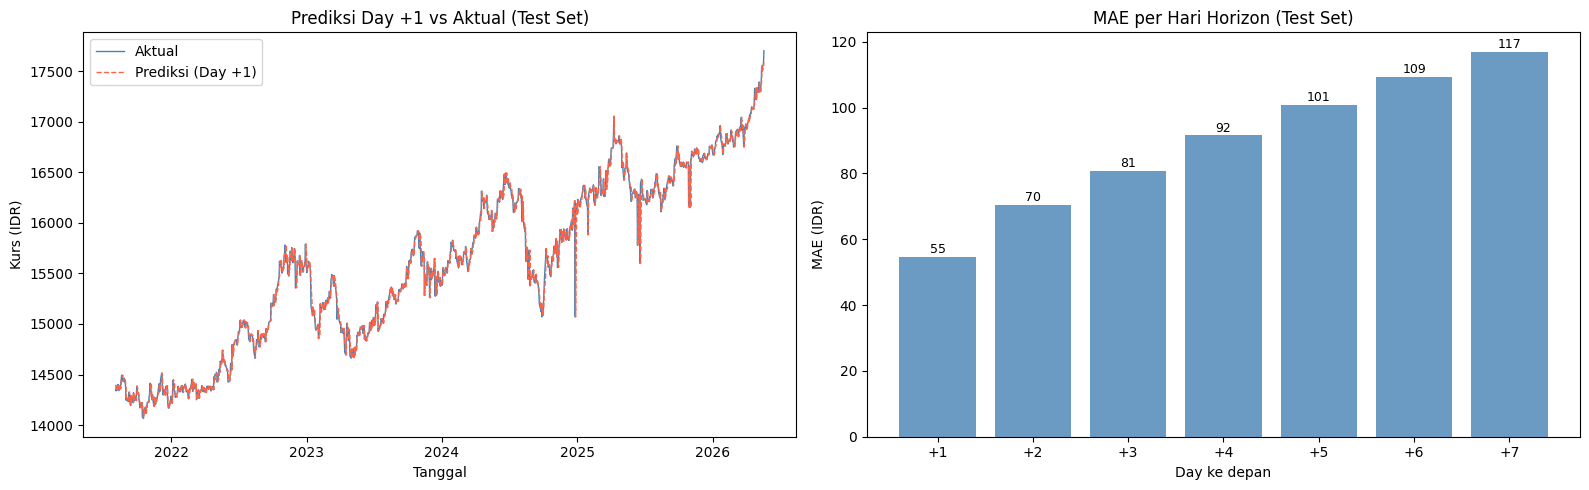

In [6]:
# ============================================================
# Cell 6 — Evaluasi test set
# Prediksi → inverse scaling → rekonstruksi harga → MAE/RMSE per hari
# ============================================================

# === Prediksi test set (deterministik, tanpa dropout) ===
y_pred_scaled = model.predict(X_test, verbose=0)

# === Inverse scaling (pakai feat_scaler kolom 0 via helper) ===
y_pred_diff = inverse_close_diff(y_pred_scaled).reshape(y_pred_scaled.shape)
y_true_diff = inverse_close_diff(y_test).reshape(y_test.shape)

# === Rekonstruksi harga ===
# Indexing: feat row j ↔ df row (j + SKIP). Untuk test sample t, "current price" =
# data_raw[SKIP + split + t + WINDOW - 1] (close pada hari terakhir window input).
start_prices = data_raw[SKIP + split + WINDOW - 1 : SKIP + split + WINDOW - 1 + len(y_test)]
y_pred_price = start_prices[:, None] + np.cumsum(y_pred_diff, axis=1)
y_true_price = start_prices[:, None] + np.cumsum(y_true_diff, axis=1)

# === MAE/RMSE per hari horizon (lihat error growth) ===
per_day_mae  = np.mean(np.abs(y_pred_price - y_true_price), axis=0)
per_day_rmse = np.sqrt(np.mean((y_pred_price - y_true_price) ** 2, axis=0))
mae  = float(np.mean(per_day_mae))
rmse = float(np.mean(per_day_rmse))

print("Test Set — MAE per Hari Horizon:")
for d in range(HORIZON):
    print(f"  Day +{d+1}: MAE = {per_day_mae[d]:7.2f} IDR   RMSE = {per_day_rmse[d]:7.2f} IDR")
print(f"  Rata-rata: MAE = {mae:.2f} IDR   RMSE = {rmse:.2f} IDR")

# === Plot: line chart Day+1 + bar chart MAE per hari ===
test_dates = df.index[SKIP + split + WINDOW : SKIP + split + WINDOW + len(y_test)]
day1_pred  = y_pred_price[:, 0]
day1_true  = y_true_price[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(test_dates, day1_true, label='Aktual',            linewidth=1.0, color='steelblue')
axes[0].plot(test_dates, day1_pred, label='Prediksi (Day +1)', linewidth=1.0, color='tomato', linestyle='--')
axes[0].set_title('Prediksi Day +1 vs Aktual (Test Set)')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Kurs (IDR)')
axes[0].legend()

day_labels = [f'+{i+1}' for i in range(HORIZON)]
bars = axes[1].bar(day_labels, per_day_mae, color='steelblue', alpha=0.8)
axes[1].set_title('MAE per Hari Horizon (Test Set)')
axes[1].set_xlabel('Day ke depan')
axes[1].set_ylabel('MAE (IDR)')
for bar, v in zip(bars, per_day_mae):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + max(per_day_mae) * 0.01,
                 f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_prediksi_vs_aktual_testset.png'), dpi=150)
plt.show()

=== Metrik Evaluasi Profesional — Test Set ===
Day  MAE (IDR)  RMSE (IDR)  MAPE (%)  Dir Acc (%)  Theil's U
 +1      54.60       91.68     0.350         53.3     0.9997
 +2      70.42      107.47     0.451         53.4     0.9992
 +3      80.78      118.37     0.517         53.4     0.9984
 +4      91.52      130.02     0.586         53.4     0.9977
 +5     100.83      140.08     0.645         53.4     0.9968
 +6     109.41      150.72     0.700         53.4     0.9959
 +7     117.01      159.07     0.749         53.5     0.9950

=== Ringkasan ===
             Metrik     Nilai                                                     Interpretasi
      MAE rata-rata 89.22 IDR                                              Error IDR rata-rata
     MAPE rata-rata    0.571%                              Error relatif terhadap harga aktual
  Dir Acc rata-rata     53.4%                                  Ketepatan arah (up/down) harian
Theil's U rata-rata    0.9975 Lebih baik dari naive ✓  (U<1=baik, 

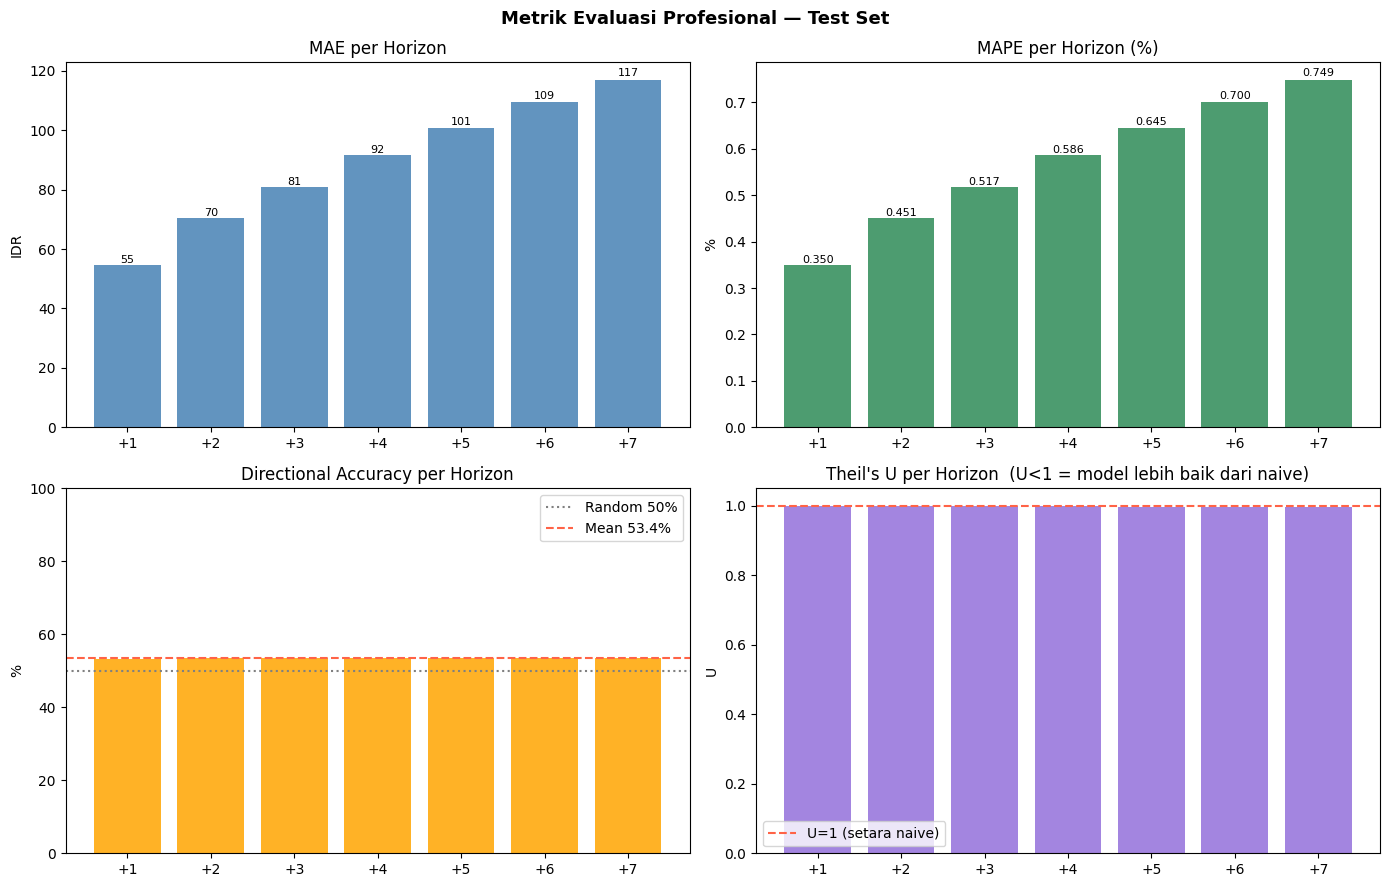

In [7]:
# ============================================================
# Cell 6b — Metrik evaluasi profesional
# Tambahan setelah Cell 6.
# Butuh: y_pred_price, y_true_price, y_pred_diff, y_true_diff,
#        start_prices, per_day_mae, per_day_rmse (dari Cell 6)
# ============================================================

# ── MAPE per horizon ──────────────────────────────────────────────────────────
mape_per_day = np.mean(
    np.abs((y_true_price - y_pred_price) / y_true_price) * 100,
    axis=0
)

# ── Directional Accuracy per horizon ─────────────────────────────────────────
# Arah harian: sign dari close_diff yang diprediksi vs aktual
da_per_day = np.mean(
    np.sign(y_pred_diff) == np.sign(y_true_diff),
    axis=0
) * 100  # shape (HORIZON,)

# ── Theil's U per horizon ─────────────────────────────────────────────────────
# Naive = random walk: prediksi harga = harga terakhir (start_prices)
# U < 1: lebih baik dari naive | U = 1: setara | U > 1: lebih buruk
naive_price  = np.repeat(start_prices[:, None], HORIZON, axis=1)
theil_u_days = []
for h in range(HORIZON):
    m_rmse = np.sqrt(np.mean((y_pred_price[:, h] - y_true_price[:, h]) ** 2))
    n_rmse = np.sqrt(np.mean((naive_price[:, h]  - y_true_price[:, h]) ** 2))
    theil_u_days.append(float(m_rmse / (n_rmse + 1e-10)))

theil_u_mean = float(np.mean(theil_u_days))  # disimpan untuk Cell 7b

# ── DataFrame ringkasan per horizon ──────────────────────────────────────────
metrics_pro = pd.DataFrame({
    'Day'         : [f'+{i+1}' for i in range(HORIZON)],
    'MAE (IDR)'   : np.round(per_day_mae,  2),
    'RMSE (IDR)'  : np.round(per_day_rmse, 2),
    'MAPE (%)'    : np.round(mape_per_day, 3),
    'Dir Acc (%)' : np.round(da_per_day,   1),
    "Theil's U"   : np.round(theil_u_days, 4),
})
print("=== Metrik Evaluasi Profesional — Test Set ===")
print(metrics_pro.to_string(index=False))

u_label = ('Lebih baik dari naive ✓' if theil_u_mean < 1
           else 'Setara naive' if abs(theil_u_mean - 1) < 0.01
           else 'Lebih buruk dari naive ✗')
print("\n=== Ringkasan ===")
print(pd.DataFrame({
    'Metrik'       : ['MAE rata-rata', 'MAPE rata-rata',
                      'Dir Acc rata-rata', "Theil's U rata-rata"],
    'Nilai'        : [f"{mae:.2f} IDR", f"{mape_per_day.mean():.3f}%",
                      f"{da_per_day.mean():.1f}%", f"{theil_u_mean:.4f}"],
    'Interpretasi' : ['Error IDR rata-rata',
                      'Error relatif terhadap harga aktual',
                      'Ketepatan arah (up/down) harian',
                      f"{u_label}  (U<1=baik, U=1=setara naive, U>1=buruk)"],
}).to_string(index=False))

# ── Plot 2×2 ──────────────────────────────────────────────────────────────────
day_labels = [f'+{i+1}' for i in range(HORIZON)]
fig, axes  = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(day_labels, per_day_mae,  color='steelblue',    alpha=0.85)
axes[0, 0].set_title('MAE per Horizon'); axes[0, 0].set_ylabel('IDR')
for i, v in enumerate(per_day_mae):
    axes[0, 0].text(i, v * 1.01, f'{v:.0f}', ha='center', fontsize=8)

axes[0, 1].bar(day_labels, mape_per_day, color='seagreen',     alpha=0.85)
axes[0, 1].set_title('MAPE per Horizon (%)'); axes[0, 1].set_ylabel('%')
for i, v in enumerate(mape_per_day):
    axes[0, 1].text(i, v * 1.01, f'{v:.3f}', ha='center', fontsize=8)

axes[1, 0].bar(day_labels, da_per_day,   color='orange',       alpha=0.85)
axes[1, 0].axhline(50, color='gray', linestyle=':', label='Random 50%')
axes[1, 0].axhline(da_per_day.mean(), color='tomato', linestyle='--',
                   label=f'Mean {da_per_day.mean():.1f}%')
axes[1, 0].set_title('Directional Accuracy per Horizon')
axes[1, 0].set_ylabel('%'); axes[1, 0].set_ylim(0, 100); axes[1, 0].legend()

axes[1, 1].bar(day_labels, theil_u_days, color='mediumpurple', alpha=0.85)
axes[1, 1].axhline(1.0, color='tomato', linestyle='--', label="U=1 (setara naive)")
axes[1, 1].set_title("Theil's U per Horizon  (U<1 = model lebih baik dari naive)")
axes[1, 1].set_ylabel('U'); axes[1, 1].legend()

plt.suptitle("Metrik Evaluasi Profesional — Test Set", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_metrics_professional.png'), dpi=150)
plt.show()

=== Backtest 7 Hari (Direct Multi-Output) ===
   Tanggal  Aktual (IDR)  Proyeksi (IDR)  Selisih (IDR)  Error (%) Arah Benar
2026-05-19         17701           17587           -113       0.64          ✓
2026-05-20         17777           17588           -188       1.06          ✓
2026-05-21         17658           17589            -68       0.39          ✗
2026-05-22         17692           17590           -101       0.57          ✓
2026-05-25         17692           17592            -99       0.56          ✗
2026-05-26         17762           17593           -168       0.95          ✓
2026-05-27         17783           17594           -188       1.06          ✓

MAE rata-rata        : 132.79 IDR
RMSE                 : 140.14 IDR
Directional Accuracy : 5/7 hari (71.4%)


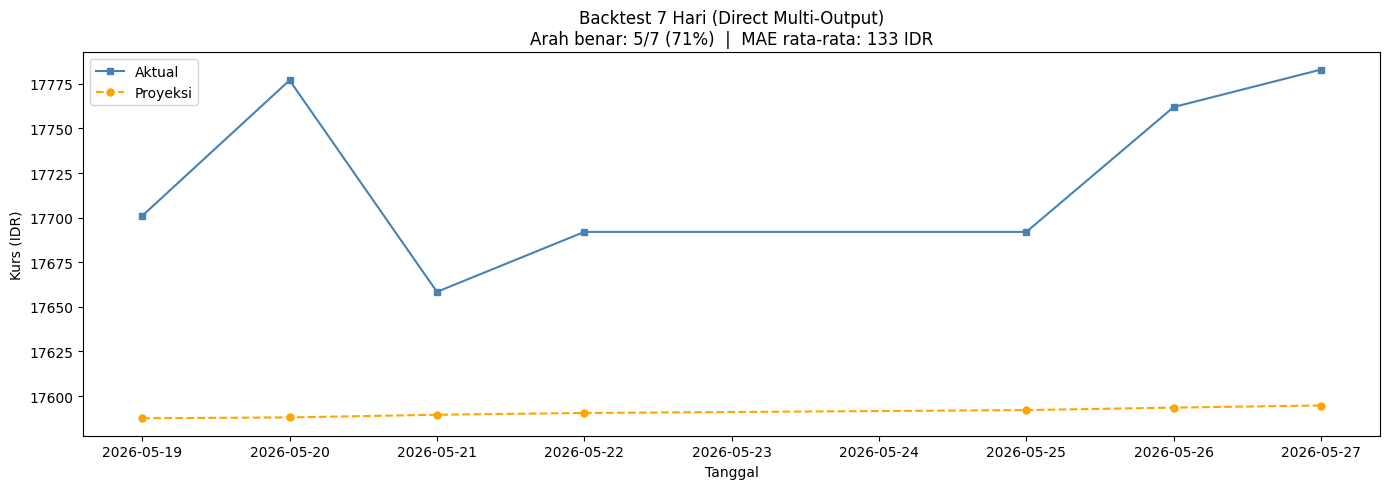

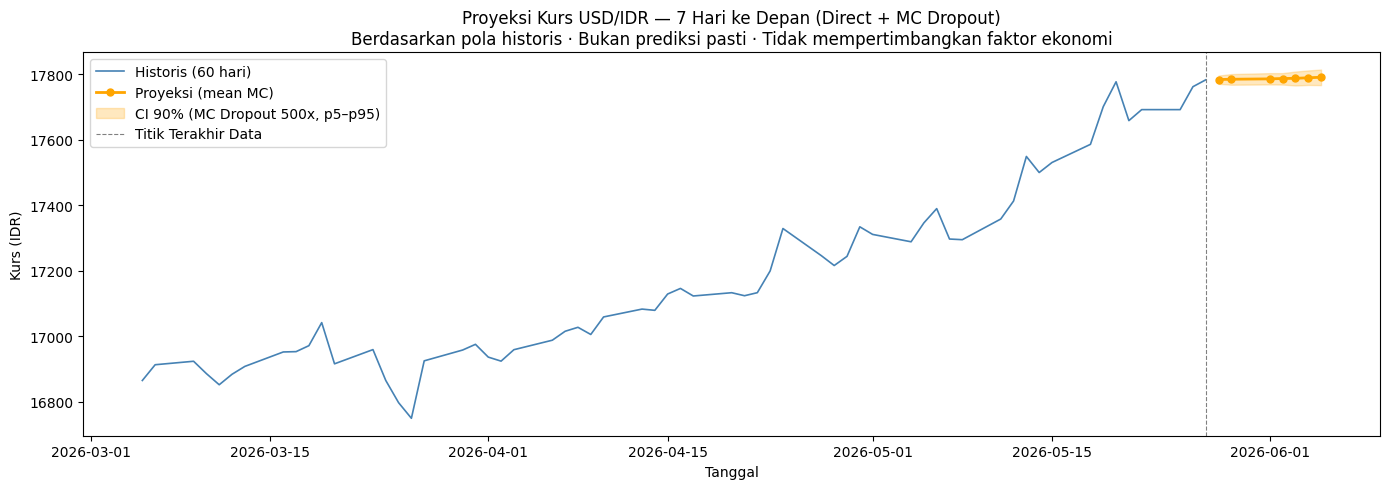


Proyeksi 7 hari ke depan (500 MC samples, CI 5%-95%):
Arah backtest benar : 5/7 hari (71.4%)

   Tanggal  Proyeksi Kurs (IDR)  CI 5% (IDR)  CI 95% (IDR)  Std (IDR)
2026-05-28                17783        17770         17795          7
2026-05-29                17784        17768         17800          9
2026-06-01                17785        17768         17803         11
2026-06-02                17786        17768         17803         10
2026-06-03                17787        17765         17808         13
2026-06-04                17789        17767         17811         14
2026-06-05                17790        17766         17814         14


In [8]:
# ============================================================
# Cell 7 — Backtest 7 hari terakhir & proyeksi 7 hari ke depan
# Backtest: prediksi langsung 7 hari sekaligus, hitung MAE/RMSE/dir per hari
# Proyeksi: MC Dropout 500x (batched untuk efisiensi), CI 5%-95%
# ============================================================

# ============ Backtest direct multi-output ============
# Ambil window terakhir SEBELUM FORECAST_DAYS hari terakhir, prediksi 7 hari sekaligus
bt_input         = features_scaled[-WINDOW - FORECAST_DAYS : -FORECAST_DAYS].reshape(1, WINDOW, N_FEATURES)
bt_start_price   = data_raw[-FORECAST_DAYS - 1]
bt_actual_prices = data_raw[-FORECAST_DAYS:]
bt_dates         = df.index[-FORECAST_DAYS:]

bt_pred_scaled = model.predict(bt_input, verbose=0)[0]
bt_pred_diff   = inverse_close_diff(bt_pred_scaled)
bt_pred_prices = bt_start_price + np.cumsum(bt_pred_diff)

# Metrik per hari (single sample → per-hari MAE = |error|, RMSE sama)
bt_per_day_err = np.abs(bt_pred_prices - bt_actual_prices)
bt_mae  = float(np.mean(bt_per_day_err))
bt_rmse = float(np.sqrt(np.mean(bt_per_day_err ** 2)))

# Directional accuracy per hari
actual_dir   = np.sign(np.diff(np.concatenate([[bt_start_price], bt_actual_prices])))
pred_dir     = np.sign(np.diff(np.concatenate([[bt_start_price], bt_pred_prices])))
dir_correct  = int(np.sum(actual_dir == pred_dir))
dir_accuracy = dir_correct / FORECAST_DAYS * 100

bt_df = pd.DataFrame({
    'Tanggal'        : bt_dates.strftime('%Y-%m-%d'),
    'Aktual (IDR)'   : bt_actual_prices.astype(int),
    'Proyeksi (IDR)' : bt_pred_prices.astype(int),
    'Selisih (IDR)'  : (bt_pred_prices - bt_actual_prices).astype(int),
    'Error (%)'      : np.round(np.abs((bt_actual_prices - bt_pred_prices) / bt_actual_prices) * 100, 2),
    'Arah Benar'     : ['✓' if a == p else '✗' for a, p in zip(actual_dir, pred_dir)],
})
print(f"=== Backtest {FORECAST_DAYS} Hari (Direct Multi-Output) ===")
print(bt_df.to_string(index=False))
print(f"\nMAE rata-rata        : {bt_mae:,.2f} IDR")
print(f"RMSE                 : {bt_rmse:,.2f} IDR")
print(f"Directional Accuracy : {dir_correct}/{FORECAST_DAYS} hari ({dir_accuracy:.1f}%)")

plt.figure(figsize=(14, 5))
plt.plot(bt_dates, bt_actual_prices, label='Aktual',   color='steelblue', linewidth=1.5, marker='s', markersize=5)
plt.plot(bt_dates, bt_pred_prices,   label='Proyeksi', color='orange',    linewidth=1.5, linestyle='--', marker='o', markersize=5)
plt.title(f'Backtest {FORECAST_DAYS} Hari (Direct Multi-Output)\n'
          f'Arah benar: {dir_correct}/{FORECAST_DAYS} ({dir_accuracy:.0f}%)  |  MAE rata-rata: {bt_mae:.0f} IDR')
plt.xlabel('Tanggal')
plt.ylabel('Kurs (IDR)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_backtest_{FORECAST_DAYS}hari.png'), dpi=150)
plt.show()

# ============ Proyeksi 7 hari ke depan via Monte Carlo Dropout ============
# Batch 500 kopi input → 1x forward pass dengan training=True
# (paralelisasi TF, jauh lebih cepat dari loop Python 500x)
last_input = features_scaled[-WINDOW:].reshape(1, WINDOW, N_FEATURES)
last_price = data_raw[-1]

mc_batch        = np.repeat(last_input, MC_SAMPLES, axis=0)
mc_preds_scaled = model(mc_batch, training=True).numpy()           # (MC_SAMPLES, HORIZON)
mc_preds_diff   = inverse_close_diff(mc_preds_scaled).reshape(MC_SAMPLES, HORIZON)
mc_preds_prices = last_price + np.cumsum(mc_preds_diff, axis=1)    # (MC_SAMPLES, HORIZON)

future_mean = mc_preds_prices.mean(axis=0)
future_p05  = np.percentile(mc_preds_prices, 5,  axis=0)
future_p95  = np.percentile(mc_preds_prices, 95, axis=0)
future_std  = mc_preds_prices.std(axis=0)

future_dates = pd.bdate_range(start=df.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-60:], data_raw[-60:], label='Historis (60 hari)', color='steelblue', linewidth=1.2)
ax.plot(future_dates, future_mean, label='Proyeksi (mean MC)', color='orange', linewidth=2, marker='o', markersize=5)
ax.fill_between(future_dates, future_p05, future_p95, color='orange', alpha=0.25,
                label=f'CI 90% (MC Dropout {MC_SAMPLES}x, p5–p95)')
ax.axvline(x=df.index[-1], color='gray', linestyle='--', linewidth=0.8, label='Titik Terakhir Data')
ax.set_title(f'Proyeksi Kurs USD/IDR — {FORECAST_DAYS} Hari ke Depan (Direct + MC Dropout)\n'
             f'Berdasarkan pola historis · Bukan prediksi pasti · Tidak mempertimbangkan faktor ekonomi')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Kurs (IDR)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_proyeksi_{FORECAST_DAYS}hari_ke_depan.png'), dpi=150)
plt.show()

pred_df = pd.DataFrame({
    'Tanggal'             : future_dates.strftime('%Y-%m-%d'),
    'Proyeksi Kurs (IDR)' : future_mean.astype(int),
    'CI 5% (IDR)'         : future_p05.astype(int),
    'CI 95% (IDR)'        : future_p95.astype(int),
    'Std (IDR)'           : future_std.astype(int),
})
print(f"\nProyeksi {FORECAST_DAYS} hari ke depan ({MC_SAMPLES} MC samples, CI 5%-95%):")
print(f"Arah backtest benar : {dir_correct}/{FORECAST_DAYS} hari ({dir_accuracy:.1f}%)\n")
print(pred_df.to_string(index=False))

=== Tabel Proyeksi + Confidence Level ===
   Tanggal  Proyeksi Kurs (IDR)  CI 5% (IDR)  CI 95% (IDR)  CI Width (IDR)  Std (IDR) Confidence
2026-05-28                17783        17770         17795              25          7     Tinggi
2026-05-29                17784        17768         17800              32          9     Tinggi
2026-06-01                17785        17768         17803              34         11     Tinggi
2026-06-02                17786        17768         17803              34         10     Tinggi
2026-06-03                17787        17765         17808              42         13     Tinggi
2026-06-04                17789        17767         17811              44         14     Tinggi
2026-06-05                17790        17766         17814              47         14     Tinggi

CATATAN METODOLOGIS
  Theil's U (test set, rata-rata)      : 0.9975  (lebih baik dari random walk ✓)
  Directional acc (backtest 7 hari)    : 71.4%  (5/7 hari benar)
  Directional a

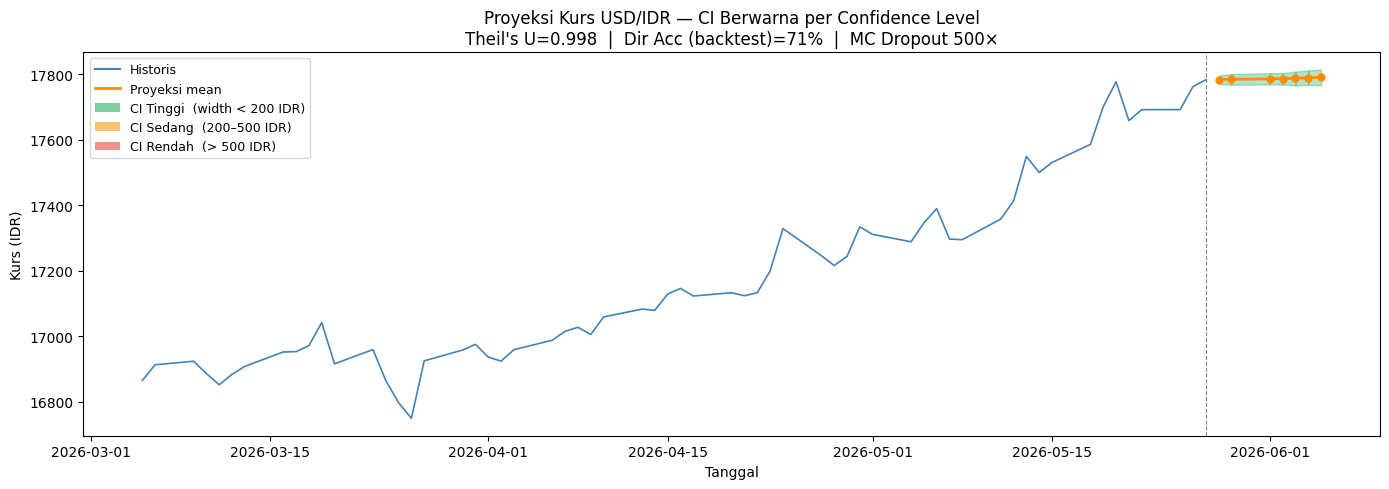

In [9]:
# ============================================================
# Cell 7b — Interpretasi CI yang diperkuat
# Tambahan setelah Cell 7. Tabel proyeksi lama dipertahankan.
# Butuh: theil_u_mean, da_per_day (Cell 6b)
#        mean_dir_wf, wf_df (Cell 4)
#        dir_accuracy, dir_correct, future_p05, future_p95,
#        future_mean, future_dates, pred_df (Cell 7)
# ============================================================
from matplotlib.patches import Patch

ci_width = future_p95 - future_p05

# ── Tambah kolom Confidence Level ─────────────────────────────────────────────
def _ci_level(width):
    """Kategorikan lebar CI (IDR) ke Tinggi/Sedang/Rendah."""
    if width < 200:   return 'Tinggi'
    elif width < 500: return 'Sedang'
    else:             return 'Rendah'

pred_df_enhanced = pred_df.copy()
pred_df_enhanced.insert(4, 'CI Width (IDR)', ci_width.astype(int))
pred_df_enhanced['Confidence'] = [_ci_level(w) for w in ci_width]

print("=== Tabel Proyeksi + Confidence Level ===")
print(pred_df_enhanced.to_string(index=False))

# ── Catatan otomatis ──────────────────────────────────────────────────────────
ci_exp_pct    = (ci_width[-1] - ci_width[0]) / (ci_width[0] + 1e-10) * 100
ci_melebar    = bool(ci_exp_pct > 50)

print(f"\n{'='*60}")
print("CATATAN METODOLOGIS")
print(f"{'='*60}")
print(f"  Theil's U (test set, rata-rata)      : {theil_u_mean:.4f}  "
      f"({'lebih baik dari random walk ✓' if theil_u_mean < 1 else 'lebih buruk dari random walk ✗'})")
print(f"  Directional acc (backtest 7 hari)    : {dir_accuracy:.1f}%  "
      f"({dir_correct}/{FORECAST_DAYS} hari benar)")
print(f"  Directional acc (walk-forward mean)  : {mean_dir_wf:.1f}%  "
      f"({len(wf_df)} fold)")
print(f"  CI Day+1                             : {ci_width[0]:.0f} IDR  "
      f"[{_ci_level(ci_width[0])}]")
print(f"  CI Day+7                             : {ci_width[-1]:.0f} IDR  "
      f"[{_ci_level(ci_width[-1])}]")
print(f"  Pelebaran CI D1→D7                   : {ci_exp_pct:.0f}%  "
      f"{'⚠ Melebar signifikan' if ci_melebar else '— Relatif stabil'}")

print("""
┌─────────────────────────────────────────────────────────────────┐
│                     ⚠  PERINGATAN  ⚠                            │
├─────────────────────────────────────────────────────────────────┤
│  PROYEKSI INI BERBASIS POLA HISTORIS.                           │
│                                                                 │
│  Kejadian luar biasa TIDAK DAPAT diprediksi model ini:          │
│  • FOMC surprise (kenaikan/penurunan suku bunga mendadak)      │
│  • Krisis geopolitik & guncangan komoditas global               │
│  • Intervensi Bank Indonesia di pasar valuta asing              │
│  • Sentimen risk-off / risk-on mendadak (flight to safety)      │
│                                                                 │
│  Confidence Interval mencerminkan ketidakpastian MODEL          │
│  (MC Dropout variance), BUKAN ketidakpastian pasar.             │
│  Ketidakpastian pasar nyata bisa jauh lebih besar.              │
│                                                                 │
│  BUKAN REKOMENDASI FINANSIAL.                                   │
└─────────────────────────────────────────────────────────────────┘
""")

# ── Plot proyeksi dengan CI berwarna per confidence level ─────────────────────
_ci_colors = {'Tinggi': '#27ae60', 'Sedang': '#f39c12', 'Rendah': '#e74c3c'}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-60:], data_raw[-60:],
        color='steelblue', linewidth=1.2, label='Historis (60 hari)')
ax.plot(future_dates, future_mean,
        color='darkorange', linewidth=2, marker='o', markersize=5,
        label='Proyeksi (mean MC)')

for i in range(len(future_dates) - 1):
    lvl = _ci_level(ci_width[i])
    ax.fill_between(
        [future_dates[i], future_dates[i + 1]],
        [future_p05[i], future_p05[i + 1]],
        [future_p95[i], future_p95[i + 1]],
        color=_ci_colors[lvl], alpha=0.35,
    )

ax.axvline(x=df.index[-1], color='gray', linestyle='--', linewidth=0.8,
           label='Titik terakhir data')

legend_elems = [
    plt.Line2D([0], [0], color='steelblue',  linewidth=1.5, label='Historis'),
    plt.Line2D([0], [0], color='darkorange', linewidth=2,   label='Proyeksi mean'),
    Patch(facecolor='#27ae60', alpha=0.6, label='CI Tinggi  (width < 200 IDR)'),
    Patch(facecolor='#f39c12', alpha=0.6, label='CI Sedang  (200–500 IDR)'),
    Patch(facecolor='#e74c3c', alpha=0.6, label='CI Rendah  (> 500 IDR)'),
]
ax.legend(handles=legend_elems, loc='upper left', fontsize=9)
ax.set_title(f"Proyeksi Kurs USD/IDR — CI Berwarna per Confidence Level\n"
             f"Theil's U={theil_u_mean:.3f}  |  Dir Acc (backtest)={dir_accuracy:.0f}%  "
             f"|  MC Dropout {MC_SAMPLES}×")
ax.set_xlabel('Tanggal'); ax.set_ylabel('Kurs (IDR)')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_proyeksi_ci_enhanced.png'), dpi=150)
plt.show()

In [ ]:
# ============================================================
# Cell 8 — Simpan summary.txt & tabel_proyeksi_*.csv ke folder Result
# ============================================================

# === Simpan tabel proyeksi ===
csv_path = os.path.join(RESULT_DIR, f'{RUN_TS}_tabel_proyeksi_{FORECAST_DAYS}hari.csv')
pred_df.to_csv(csv_path, index=False)

# === Per-day breakdown untuk summary ===
test_per_day_lines = [
    f"  Day +{d+1}: MAE = {per_day_mae[d]:7.2f} IDR  |  RMSE = {per_day_rmse[d]:7.2f} IDR"
    for d in range(HORIZON)
]
bt_per_day_lines = [
    f"  Day +{d+1}: |selisih| = {bt_per_day_err[d]:7.0f} IDR   "
    f"Arah: {'✓ benar' if actual_dir[d] == pred_dir[d] else '✗ salah'}"
    for d in range(FORECAST_DAYS)
]

summary_lines = [
    f"============================",
    f"  HASIL RUN: {RUN_TS}",
    f"============================",
    f"",
    f"[Data]",
    f"  Sumber         : Yahoo Finance (USDIDR=X)",
    f"  Rentang        : {df.index[0].date()} s.d. {df.index[-1].date()}",
    f"  Total baris    : {len(df)}",
    f"  Close terakhir : {df['Close'].iloc[-1]:,.2f} IDR  ({df.index[-1].date()})",
    f"",
    f"[Fitur Input ({N_FEATURES})]",
    f"  {', '.join(feat_names)}",
    f"",
    f"[Model]",
    f"  Arsitektur     : LSTM(64,d=0.2,rd=0.3,l2) → Dropout(0.3) → MHA(2h,k=32)+LN → LSTM(32,d=0.2,rd=0.3,l2) → Dropout(0.3) → Dense({HORIZON})",
    f"  Loss           : MSE + 0.3 × directional penalty",
    f"  Strategi       : Direct multi-output ({HORIZON} hari sekaligus, bukan autoregressive)",
    f"  Window         : {WINDOW} hari",
    f"  Skip warmup    : {SKIP} hari",
    f"  Split          : 80% train / 20% test",
    f"  Epochs run     : {len(history.history['loss'])}",
    f"  Train Loss     : {history.history['loss'][-1]:.6f}",
    f"  Val Loss       : {history.history['val_loss'][-1]:.6f}",
    f"",
    f"[Test Set — MAE per Hari Horizon]",
    *test_per_day_lines,
    f"  Rata-rata: MAE = {mae:.2f} IDR  |  RMSE = {rmse:.2f} IDR",
    f"",
    f"[Backtest {FORECAST_DAYS} Hari Terakhir — Per Hari]",
    *bt_per_day_lines,
    f"  Rata-rata: MAE = {bt_mae:,.2f} IDR  |  RMSE = {bt_rmse:,.2f} IDR",
    f"  Directional Accuracy: {dir_correct}/{FORECAST_DAYS} ({dir_accuracy:.1f}%)",
    f"",
    f"[Proyeksi {FORECAST_DAYS} Hari ke Depan — MC Dropout {MC_SAMPLES}x, CI 5%-95%]",
    pred_df.to_string(index=False),
    f"",
    f"[Kesimpulan]",
    f"  Model LSTM direct multi-output dengan {N_FEATURES} fitur input",
    f"  ({', '.join(feat_names)})",
    f"  memprediksi {FORECAST_DAYS} hari sekaligus, bukan autoregressive,",
    f"  sehingga error tidak terakumulasi antar hari.",
    f"  Loss training menggabungkan MSE dan penalty arah (alpha=0.3)",
    f"  untuk memaksa model belajar arah pergerakan.",
    f"  Pada backtest, arah pergerakan benar {dir_correct} dari {FORECAST_DAYS} hari ({dir_accuracy:.0f}%).",
    f"  Confidence interval dihitung via Monte Carlo Dropout ({MC_SAMPLES} samples)",
    f"  dengan dropout aktif pada input, recurrent, dan hidden state LSTM.",
    f"",
    f"[Keterbatasan Model]",
    f"  - Menggunakan 20 fitur teknikal & fundamental; tidak dapat memprediksi",
    f"    kejadian luar biasa (FOMC surprise, krisis geopolitik, intervensi BI mendadak)",
    f"  - Proyeksi ini BUKAN rekomendasi finansial",
    f"  - Model cenderung mengikuti tren historis (kurs naik jangka panjang)",
    f"  - MC Dropout CI mencerminkan ketidakpastian MODEL, bukan ketidakpastian PASAR",
    f"    (ketidakpastian pasar nyata bisa jauh lebih besar)",
    f"  - Akurasi menurun signifikan jika terjadi peristiwa ekonomi tak terduga",
    f"",
    f"[File Output]",
    f"  {RUN_TS}_historis_kurs_usdidr.png",
    f"  {RUN_TS}_walkforward.png",
    f"  {RUN_TS}_loss_training.png",
    f"  {RUN_TS}_prediksi_vs_aktual_testset.png",
    f"  {RUN_TS}_metrics_professional.png",
    f"  {RUN_TS}_backtest_{FORECAST_DAYS}hari.png",
    f"  {RUN_TS}_proyeksi_{FORECAST_DAYS}hari_ke_depan.png",
    f"  {RUN_TS}_proyeksi_ci_enhanced.png",
    f"  {RUN_TS}_tabel_proyeksi_{FORECAST_DAYS}hari.csv",
    f"  {RUN_TS}_summary.txt",
]

txt_path = os.path.join(RESULT_DIR, f'{RUN_TS}_summary.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines))

print('\n'.join(summary_lines))
print(f"\nSemua output tersimpan di:\n  {RESULT_DIR}")